In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

train = pd.read_csv('../data/cleaned_sales.csv')
train['date'] = pd.to_datetime(train['date'])
train.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,month,is_holiday,day_of_week,on_promo
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,1,1,Tuesday,0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,1,1,Tuesday,0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,1,1,Tuesday,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,1,1,Tuesday,0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,1,1,Tuesday,0


In [2]:
subset = train[(train['store_nbr']==1) & (train['family']=='GROCERY I')]
subset = subset[['date','sales']].sort_values('date')
subset.columns = ['ds','y']   # Prophet requires these exact column names
subset.head()

,ds,y
12,2013-01-01,0.0
1794,2013-01-02,2652.0
3576,2013-01-03,2121.0
5358,2013-01-04,2056.0
7140,2013-01-05,2216.0


In [3]:
model = Prophet()
model.fit(subset)


13:38:05 - cmdstanpy - INFO - Chain [1] start processing
13:38:06 - cmdstanpy - INFO - Chain [1] done processing


In [4]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
1704,2017-09-05,2803.367465,2177.906722,3397.455086
1705,2017-09-06,3162.434520,2526.326129,3798.134180
1706,2017-09-07,2618.046981,2004.589661,3217.206448
1707,2017-09-08,2799.935412,2243.555380,3425.226457
1708,2017-09-09,2703.320771,2093.703572,3294.998054
1709,2017-09-10,1411.795136,755.086590,2014.063388
1710,2017-09-11,2759.083576,2164.133219,3385.358157
1711,2017-09-12,2785.630301,2139.228649,3360.901301
1712,2017-09-13,3148.962075,2527.939359,3740.521355
1713,2017-09-14,2610.289568,2014.446325,3223.149803


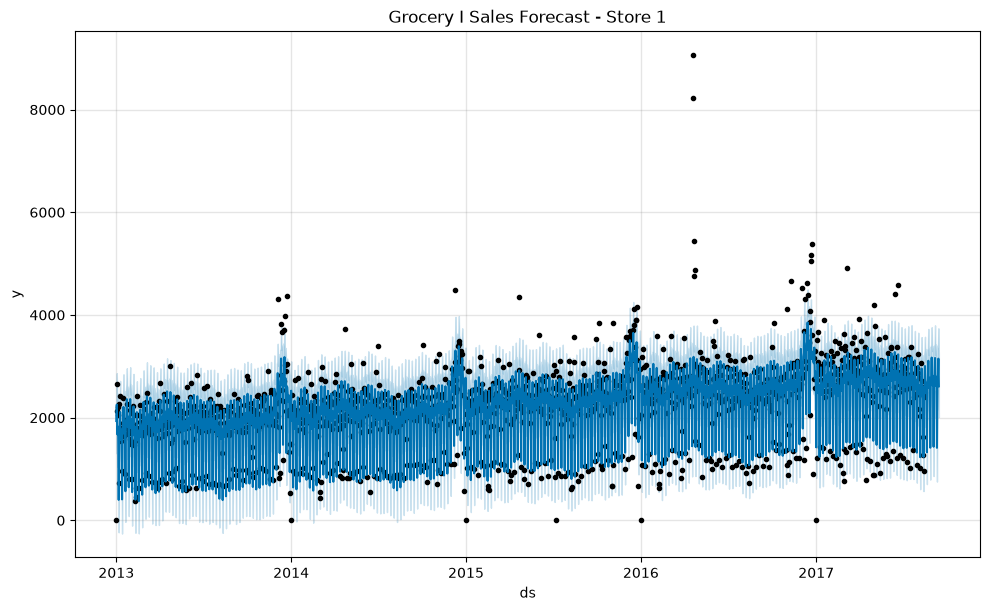

In [5]:
fig1 = model.plot(forecast)
plt.title('Grocery I Sales Forecast - Store 1')
plt.savefig('prophet_forecast.png')
plt.show()

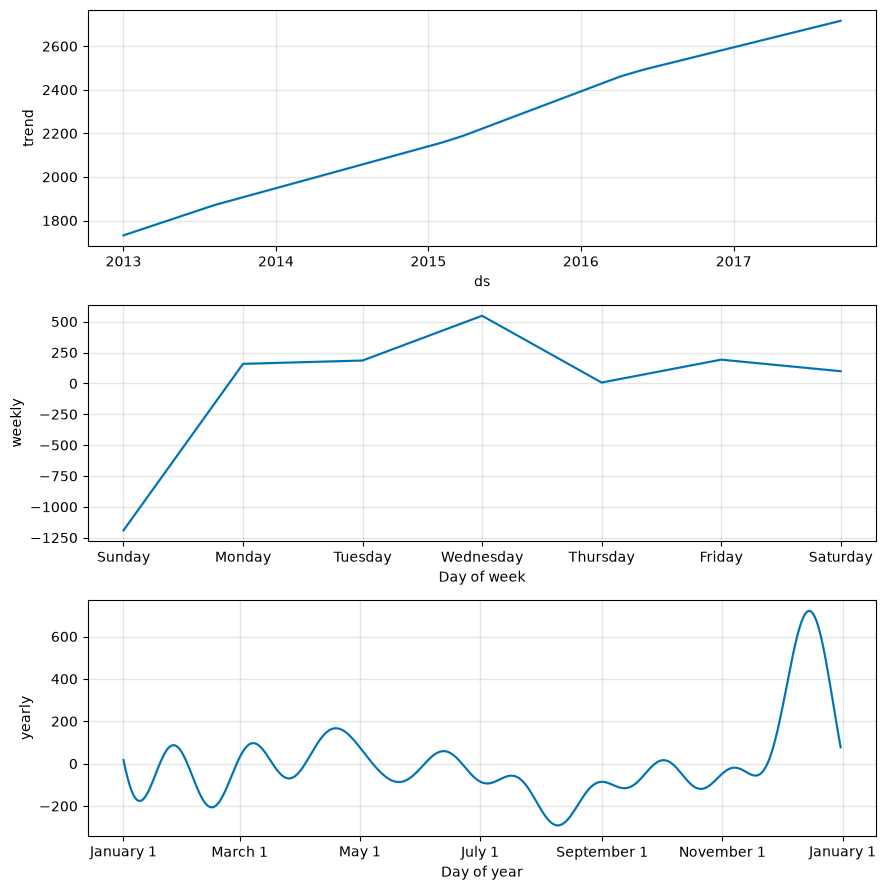

In [6]:
fig2 = model.plot_components(forecast)
plt.savefig('prophet_components.png')
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

# Compare last 30 days actual vs predicted
actual = subset['y'].values[-30:]
predicted = forecast['yhat'].values[-60:-30]  # last 30 days of historical predictions

mape = mean_absolute_percentage_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
print(f"MAPE: {mape:.2%}")
print(f"RMSE: {rmse:.2f}")

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
|